In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects
from PIL import Image

# ---------- 1) Utils: read image / mask ----------
def _read_rgb(path):
    img = Image.open(path).convert("RGB")
    return np.array(img, dtype=np.uint8)

def _read_fov_mask(path, ref_shape):
    """
    Returns a boolean mask (H, W) where True = inside FOV.
    If path is None or missing, returns an all-True mask with ref_shape.
    Accepts grayscale or RGB masks (non-zero => inside).
    """
    if (path is None) or (not os.path.exists(path)):
        return np.ones(ref_shape[:2], dtype=bool)
    m = Image.open(path)
    if m.mode != "L":
        m = m.convert("L")
    m = np.array(m, dtype=np.uint8)
    # if shape mismatches, resize to ref_shape (nearest)
    if m.shape != ref_shape[:2]:
        m = np.array(Image.fromarray(m).resize((ref_shape[1], ref_shape[0]), resample=Image.NEAREST))
    return m > 0

# ---------- 2) Detect fovea (cyan dot ~ #00FFF0) ----------
def find_fovea_xy_from_cyan(fovea_img_path, ref_shape=None, tol=40):
    """
    Finds the centroid of cyan-ish pixels. Default looks for R<40, G>215, B>200.
    Returns (fx, fy) in the coordinate system of 'ref_shape' if provided, else in fovea image coords.
    """
    fov_img = _read_rgb(fovea_img_path)
    Hf, Wf, _ = fov_img.shape
    R, G, B = fov_img[...,0], fov_img[...,1], fov_img[...,2]

    # Robust-ish threshold around (0,255,240)
    mask = (R <= tol) & (G >= 255 - tol) & (B >= 240 - tol)
    if not mask.any():
        # broader fallback: hue-ish cyan
        mask = (R < 80) & (G > 170) & (B > 170)

    if not mask.any():
        raise ValueError(f"[fovea] cyan dot not found in {fovea_img_path}")

    ys, xs = np.nonzero(mask)
    fy = float(np.mean(ys))
    fx = float(np.mean(xs))

    if ref_shape is not None and (ref_shape[0] != Hf or ref_shape[1] != Wf):
        sy = ref_shape[0] / Hf
        sx = ref_shape[1] / Wf
        fy *= sy
        fx *= sx

    return fx, fy  # (x, y)

# ---------- 3) Quadrant labels by laterality ----------
def quadrant_labels(laterality):
    """
    Returns labels for the 4 quadrants (TL, TR, BL, BR) given laterality.
    Superior = top, Inferior = bottom. For nasal/temporal:
      - RIGHT eye: left of fovea = Nasal, right = Temporal
      - LEFT  eye: left of fovea = Temporal, right = Nasal
    """
    lat = str(laterality).strip().lower()
    if lat.startswith('r'):
        left_L, right_L = "Nasal", "Temporal"
    else:
        left_L, right_L = "Temporal", "Nasal"

    return {
        "TL": f"Superior-{left_L}",
        "TR": f"Superior-{right_L}",
        "BL": f"Inferior-{left_L}",
        "BR": f"Inferior-{right_L}",
    }

# ---------- 4) Build colored overlay ----------
def build_quadrant_overlay(img_rgb, fov_mask, fx, fy, laterality, alpha=0.22):
    """
    Returns an RGBA overlay (H,W,4) with per-quadrant colors, clipped to fov_mask.
    """
    H, W, _ = img_rgb.shape
    yy, xx = np.ogrid[:H, :W]

    left   = (xx <  fx)
    right  = ~left
    top    = (yy <  fy)
    bottom = ~top

    labels = quadrant_labels(laterality)

    # Colors for the 4 quadrants (R,G,B,alpha), tweak as you like:
    # TL=SN or ST; TR=ST or SN; BL=IN or IT; BR=IT or IN
    col_TL = (1.00, 0.35, 0.75, alpha)   # magenta-ish
    col_TR = (1.00, 0.85, 0.00, alpha)   # yellow
    col_BL = (0.00, 0.80, 0.30, alpha)   # green
    col_BR = (0.00, 0.75, 1.00, alpha)   # cyan

    overlay = np.zeros((H, W, 4), dtype=float)

    sel_TL = (top & left  & fov_mask)
    sel_TR = (top & right & fov_mask)
    sel_BL = (bottom & left  & fov_mask)
    sel_BR = (bottom & right & fov_mask)

    overlay[sel_TL, :3] = col_TL[:3]; overlay[sel_TL, 3] = col_TL[3]
    overlay[sel_TR, :3] = col_TR[:3]; overlay[sel_TR, 3] = col_TR[3]
    overlay[sel_BL, :3] = col_BL[:3]; overlay[sel_BL, 3] = col_BL[3]
    overlay[sel_BR, :3] = col_BR[:3]; overlay[sel_BR, 3] = col_BR[3]

    return overlay, labels

# ---------- 5) Pretty labeling ----------
def _draw_text(ax, x, y, txt, fs=12):
    pe = [patheffects.withStroke(linewidth=3, foreground='black', alpha=0.6)]
    t = ax.text(x, y, txt, color="white", fontsize=fs, ha="center", va="center")
    t.set_path_effects(pe)

def show_regions_for_group(group_name, img_paths, fov_paths, fovea_paths, lateralities, alpha=0.22, max_cols=3):
    """
    Loops through images and displays:
      - original fundus
      - crosshair through fovea
      - N/T/S/I quadrants shaded by laterality
      - labels on each quadrant
      - clipped to FOV if provided
    """
    assert len(img_paths) == len(fovea_paths) == len(lateralities), "List lengths must match"
    if fov_paths is None: fov_paths = [None]*len(img_paths)
    elif len(fov_paths) != len(img_paths):  # be forgiving
        # pad/truncate
        fov_paths = (fov_paths + [None]*len(img_paths))[:len(img_paths)]

    n = len(img_paths)
    cols = min(max_cols, n)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5.2*rows))
    axes = np.array(axes).reshape(rows, cols)
    fig.suptitle(f"{group_name}: Quadrant regions (Nasal/Temporal/Superior/Inferior)", y=0.98, fontsize=14)

    for i, (p_img, p_fov, p_fovep, lat) in enumerate(zip(img_paths, fov_paths, fovea_paths, lateralities)):
        r, c = divmod(i, cols)
        ax = axes[r, c]

        img = _read_rgb(p_img)
        H, W, _ = img.shape
        fov_mask = _read_fov_mask(p_fov, img.shape)

        # find fovea in fovea image coords and map to img coords if needed
        fx, fy = find_fovea_xy_from_cyan(p_fovep, ref_shape=img.shape[:2])

        ax.imshow(img); ax.axis("off")
        ax.set_title(f"{os.path.basename(p_img)}  • {lat.capitalize()} eye", fontsize=10)

        # overlay
        overlay, labels = build_quadrant_overlay(img, fov_mask, fx, fy, lat, alpha=alpha)
        ax.imshow(overlay)

        # crosshair through fovea
        ax.axvline(fx, color="white", linewidth=1)
        ax.axhline(fy, color="white", linewidth=1)

        # fovea marker
        ax.scatter([fx], [fy], s=70, marker="x", c="cyan", linewidths=1.8)

        # label each quadrant roughly at its center
        _draw_text(ax, x=fx/2,       y=fy/2,        txt=labels["TL"], fs=11)
        _draw_text(ax, x=(fx+W)/2,   y=fy/2,        txt=labels["TR"], fs=11)
        _draw_text(ax, x=fx/2,       y=(fy+H)/2,    txt=labels["BL"], fs=11)
        _draw_text(ax, x=(fx+W)/2,   y=(fy+H)/2,    txt=labels["BR"], fs=11)

    # hide unused axes
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()


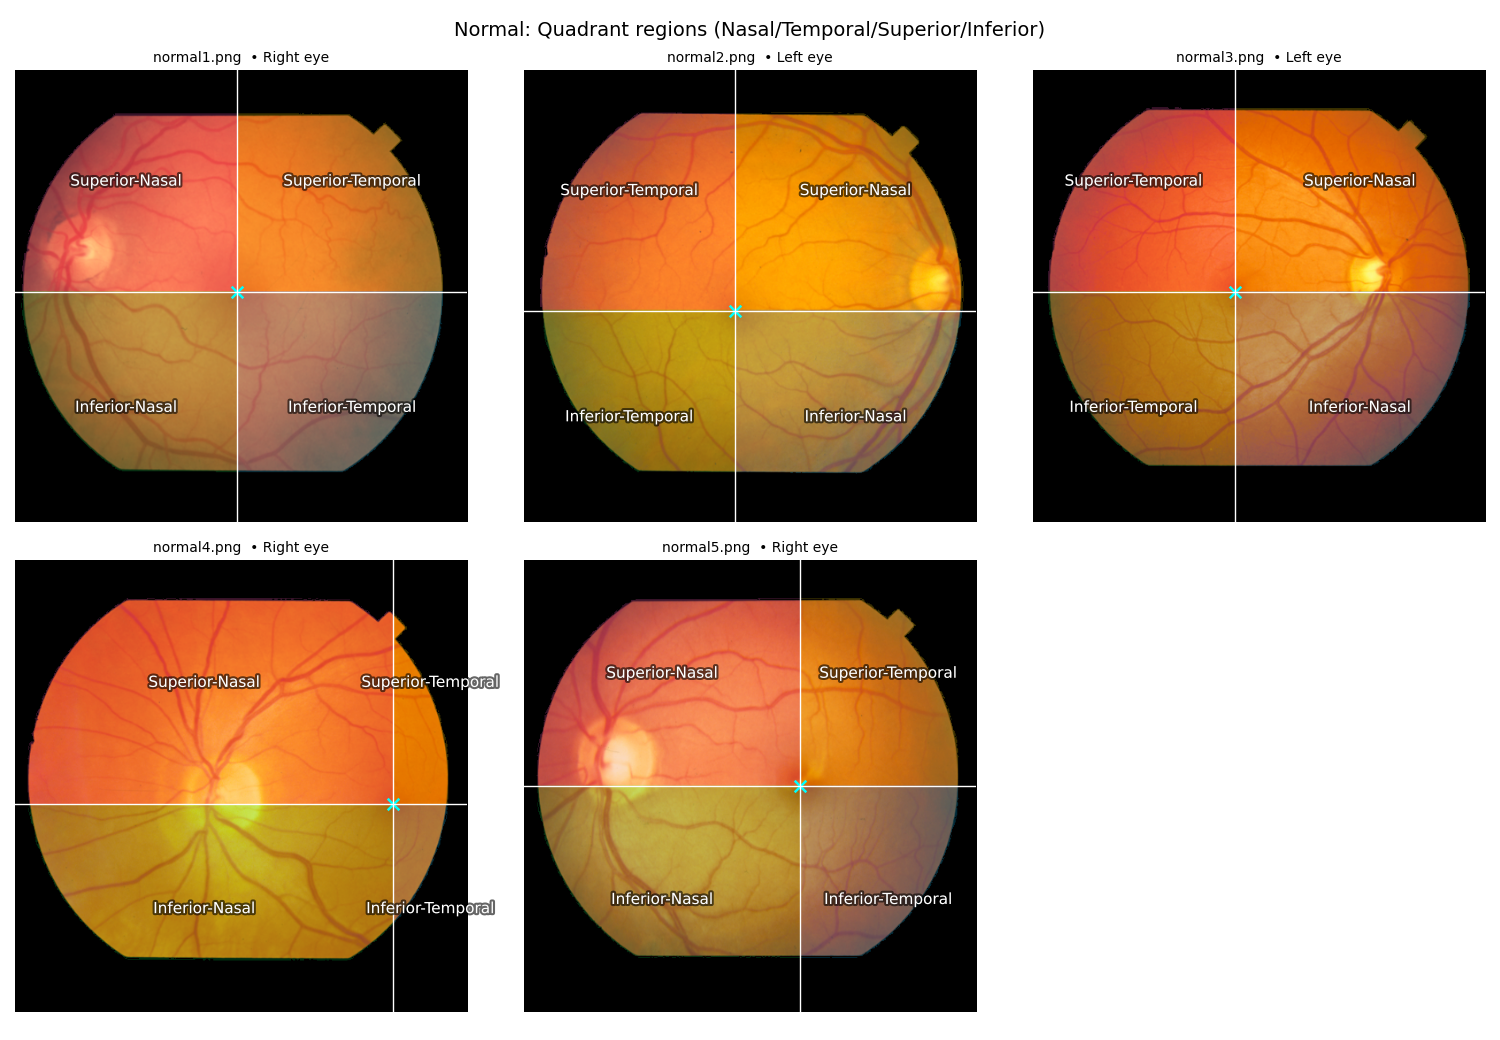

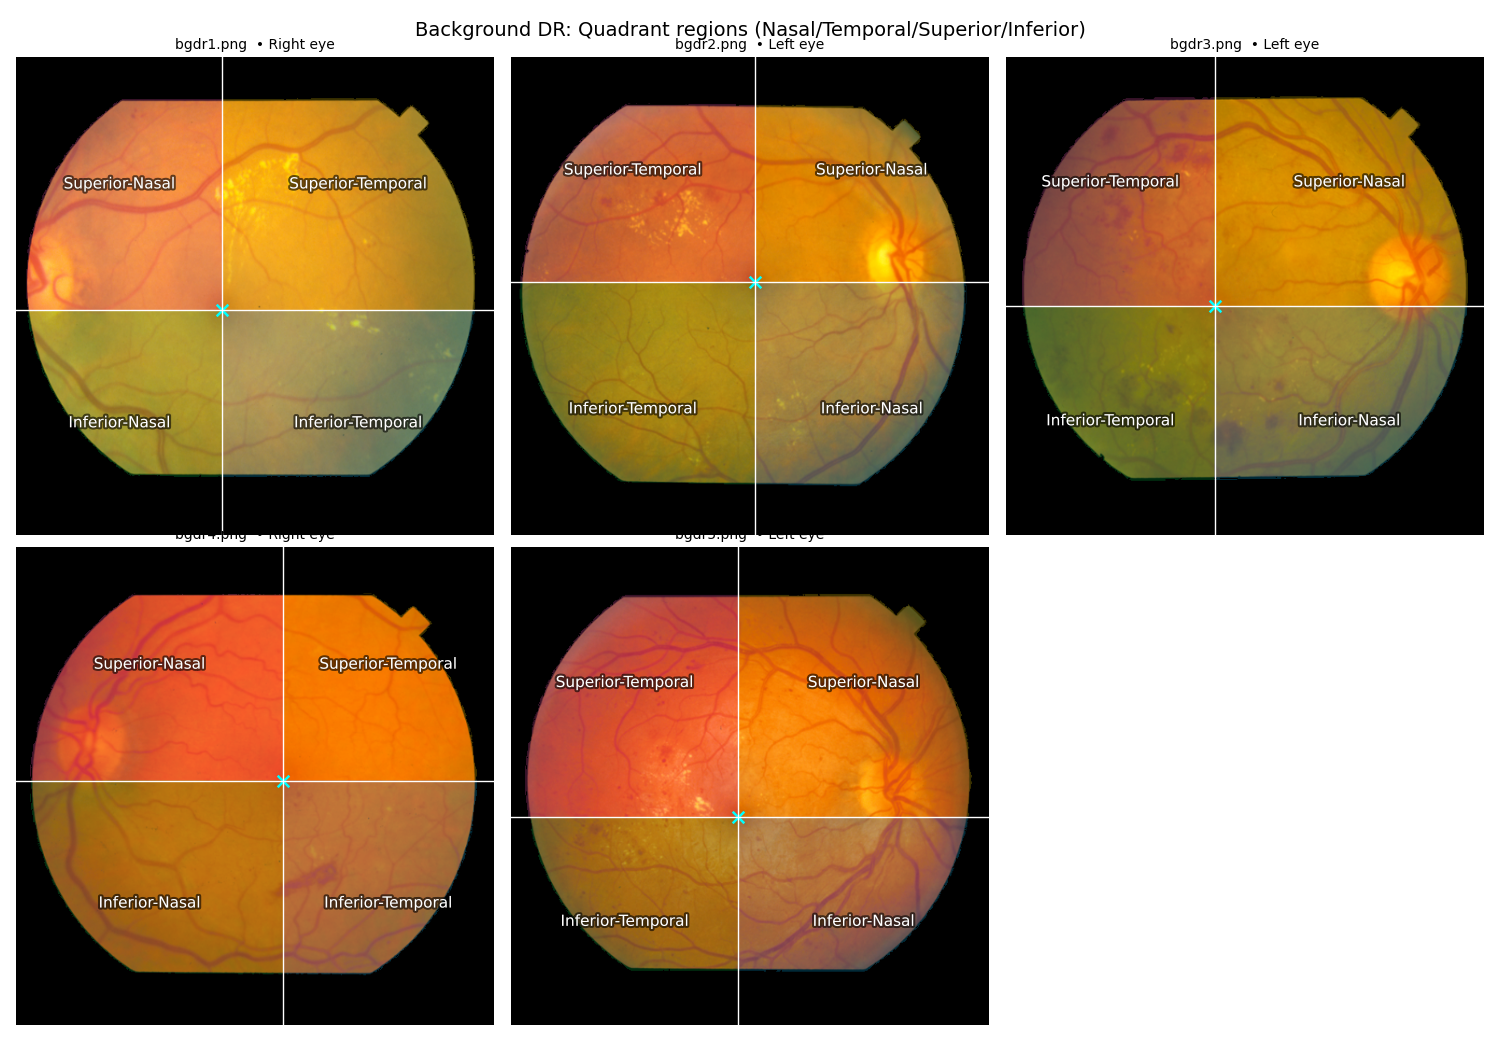

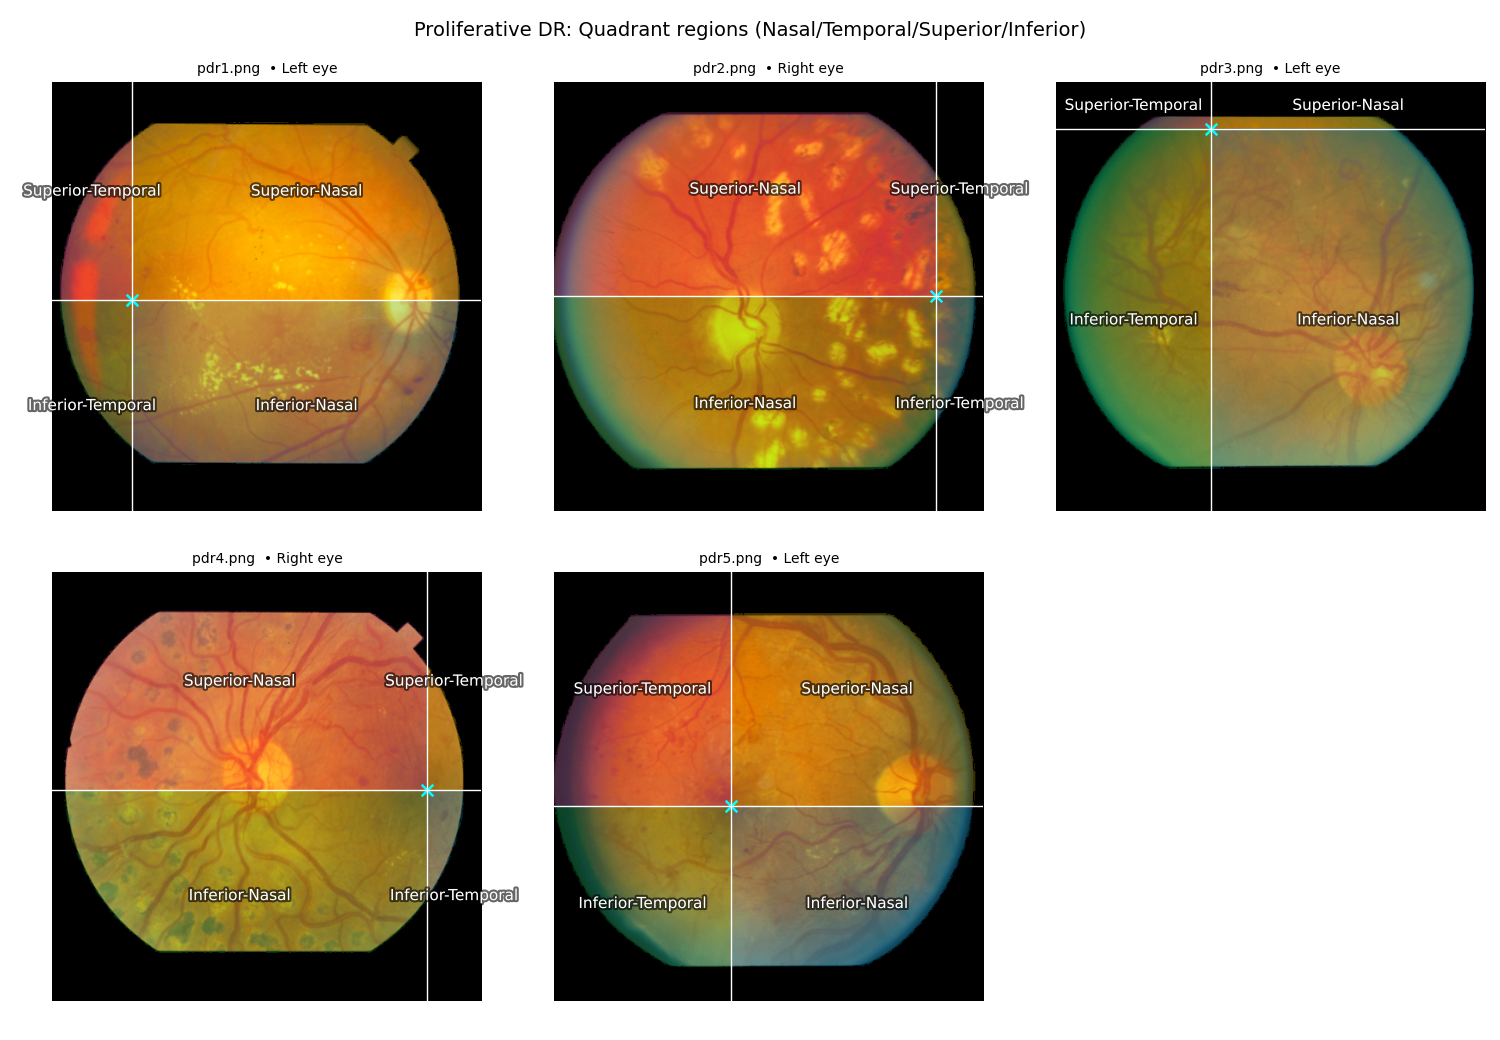

In [6]:
# --- Your paths (as provided) ---
normal_paths = [
    "../../data/raw/DR_sampleset/normal1.png", # right
    "../../data/raw/DR_sampleset/normal2.png", # left
    "../../data/raw/DR_sampleset/normal3.png", # left
    "../../data/raw/DR_sampleset/normal4.png", # right
    "../../data/raw/DR_sampleset/normal5.png", # right
]
bgdr_paths = [
    "../../data/raw/DR_sampleset/bgdr1.png", # right
    "../../data/raw/DR_sampleset/bgdr2.png", # left
    "../../data/raw/DR_sampleset/bgdr3.png", # left
    "../../data/raw/DR_sampleset/bgdr4.png", # right
    "../../data/raw/DR_sampleset/bgdr5.png", # left
]
pdr_paths = [
    "../../data/raw/DR_sampleset/pdr1.png", # left
    "../../data/raw/DR_sampleset/pdr2.png", # right 
    "../../data/raw/DR_sampleset/pdr3.png", # left
    "../../data/raw/DR_sampleset/pdr4.png", # right  
    "../../data/raw/DR_sampleset/pdr5.png", # left
] 

normal_paths_fovea = [
    "../../data/raw/DR_sampleset/normal1_fovea.png",
    "../../data/raw/DR_sampleset/normal2_fovea.png",
    "../../data/raw/DR_sampleset/normal3_fovea.png",
    "../../data/raw/DR_sampleset/normal4_fovea.png",
    "../../data/raw/DR_sampleset/normal5_fovea.png",
]
bgdr_paths_fovea = [
    "../../data/raw/DR_sampleset/bgdr1_fovea.png",
    "../../data/raw/DR_sampleset/bgdr2_fovea.png",
    "../../data/raw/DR_sampleset/bgdr3_fovea.png",
    "../../data/raw/DR_sampleset/bgdr4_fovea.png",
    "../../data/raw/DR_sampleset/bgdr5_fovea.png",
]
pdr_paths_fovea = [
    "../../data/raw/DR_sampleset/pdr1_fovea.png",
    "../../data/raw/DR_sampleset/pdr2_fovea.png",
    "../../data/raw/DR_sampleset/pdr3_fovea.png",
    "../../data/raw/DR_sampleset/pdr4_fovea.png",
    "../../data/raw/DR_sampleset/pdr5_fovea.png",
]

# NOTE: your normal_paths_fov currently points to bgdr* files in the question.
# If you actually have normal*_fov.png files, swap them in here:
normal_paths_fov = [
    # If you DON'T have FOV for normals, you can also set to [None, ...]
    "../../data/raw/DR_sampleset/normal1_fov.png",
    "../../data/raw/DR_sampleset/normal2_fov.png",
    "../../data/raw/DR_sampleset/normal3_fov.png",
    "../../data/raw/DR_sampleset/normal4_fov.png",
    "../../data/raw/DR_sampleset/normal5_fov.png",
]
bgdr_paths_fov = [
    "../../data/raw/DR_sampleset/bgdr1_fov.png",
    "../../data/raw/DR_sampleset/bgdr2_fov.png",
    "../../data/raw/DR_sampleset/bgdr3_fov.png",
    "../../data/raw/DR_sampleset/bgdr4_fov.png",
    "../../data/raw/DR_sampleset/bgdr5_fov.png",
]
pdr_paths_fov = [
    "../../data/raw/DR_sampleset/pdr1_fov.png",
    "../../data/raw/DR_sampleset/pdr2_fov.png",
    "../../data/raw/DR_sampleset/pdr3_fov.png",
    "../../data/raw/DR_sampleset/pdr4_fov.png",
    "../../data/raw/DR_sampleset/pdr5_fov.png",
]

# Laterality lists aligned with the comments you provided:
normal_lat = ["right", "left", "left", "right", "right"]
bgdr_lat   = ["right", "left", "left", "right", "left"]
pdr_lat    = ["left",  "right","left",  "right","left"]

# Show each group (set alpha lower/higher if you want more/less tint)
show_regions_for_group("Normal", normal_paths, normal_paths_fov, normal_paths_fovea, normal_lat, alpha=0.22)
show_regions_for_group("Background DR", bgdr_paths, bgdr_paths_fov, bgdr_paths_fovea, bgdr_lat, alpha=0.22)
show_regions_for_group("Proliferative DR", pdr_paths, pdr_paths_fov, pdr_paths_fovea, pdr_lat, alpha=0.22)
